### problem Definition and understanding
- With growing demands and cut-throat competitions in the market, a Superstore Giant is seeking your knowledge in understanding what works best for them. They would like to understand which products, regions, categories and customer segments they should target or avoid

- You can even take this a step further and try and build a Regression model to predict Sales or Profit.

###  Data understanding
- Row ID => Unique ID for each row.
- Order ID => Unique Order ID for each Customer.
- Order Date => Order Date of the product.
- Ship Date => Shipping Date of the Product.
- Ship Mode=> Shipping Mode specified by the Customer.
- Customer ID => Unique ID to identify each Customer.
- Customer Name => Name of the Customer.
- Segment => The segment where the Customer belongs.
- Country => Country of residence of the Customer.
- City => City of residence of of the Customer.
- State => State of residence of the Customer.
- Postal Code => Postal Code of every Customer.
- Region => Region where the Customer belong.
- Product ID => Unique ID of the Product.
- Category => Category of the product ordered.
- Sub-Category => Sub-Category of the product ordered.
- Product Name => Name of the Product
- Sales => Sales of the Product.
- Quantity => Quantity of the Product.
- Discount => Discount provided.
- Profit => Profit/Loss incurred

## install libraries

In [99]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')
%matplotlib inline
import os

In [7]:
df = pd.read_csv("Sample - Superstore.csv", encoding_errors="ignore")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Checking data type and missing values

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [9]:
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [100]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

### statistical Information 

In [10]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [12]:
df.duplicated().sum()

0

### categorical features

In [13]:
df_cat = df[[ 'Ship Mode', 'Customer ID', 'Customer Name',
             'Segment', 'Country', 'City', 'State', 'Region',
             'Product ID', 'Category', 'Sub-Category', 'Product Name']]

In [14]:
df_cat.head()


,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name
0,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase
1,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,..."
2,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...
3,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table
4,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System


### shown the number of unique values

In [15]:
for feature in df_cat.columns:
    print(feature,':',df[feature].nunique())

Ship Mode : 4
Customer ID : 793
Customer Name : 793
Segment : 3
Country : 1
City : 531
State : 49
Region : 4
Product ID : 1862
Category : 3
Sub-Category : 17
Product Name : 1850


In [17]:
df['Order Date'].nunique()

1237

In [18]:
df['Ship Date'].nunique()

1334

## Exploratory Data Analysis - EDA

### What are the top selling products in the superstore 

In [20]:
product_group = df.groupby(["Product Name"]).sum()["Sales"]
product_group.head()

Product Name
"While you Were Out" Message Book, One Form per Page     25.228
#10 Gummed Flap White Envelopes, 100/Box                 41.300
#10 Self-Seal White Envelopes                           108.682
#10 White Business Envelopes,4 1/8 x 9 1/2              488.904
#10- 4 1/8" x 9 1/2" Recycled Envelopes                 286.672
Name: Sales, dtype: float64

In [21]:
# Sort the data by sales in descending order
top_selling_products = product_group.sort_values(ascending=False)

In [22]:
top_5_selling_products = pd.DataFrame(top_selling_products[:5])
top_5_selling_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479


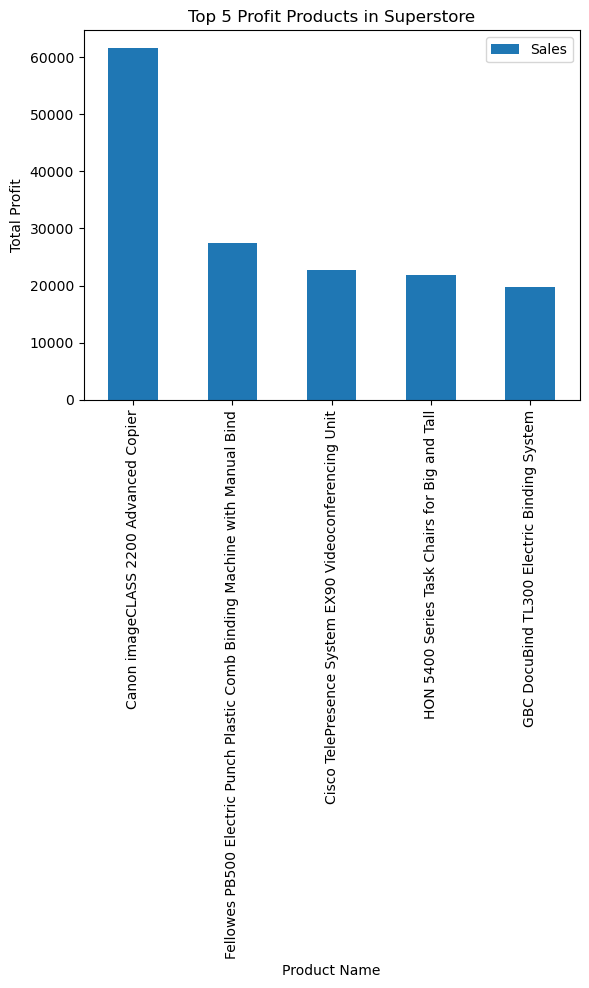

In [27]:
top_5_selling_products.plot(kind="bar")

plt.title("Top 5 Profit Products in Superstore")

plt.xlabel("Product Name")
plt.ylabel("Total Profit")

plt.show()

### top-profitable products 

In [28]:
product_group = df.groupby(["Product Name"]).sum()["Profit"]

top_profit_products = product_group.sort_values(ascending=False)

top_5_profit_products =pd.DataFrame(top_profit_products[:5])
top_5_profit_products


,Profit
Product Name,
Canon imageCLASS 2200 Advanced Copier,25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,7753.0390
Hewlett Packard LaserJet 3310 Copier,6983.8836
Canon PC1060 Personal Laser Copier,4570.9347
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",4094.9766


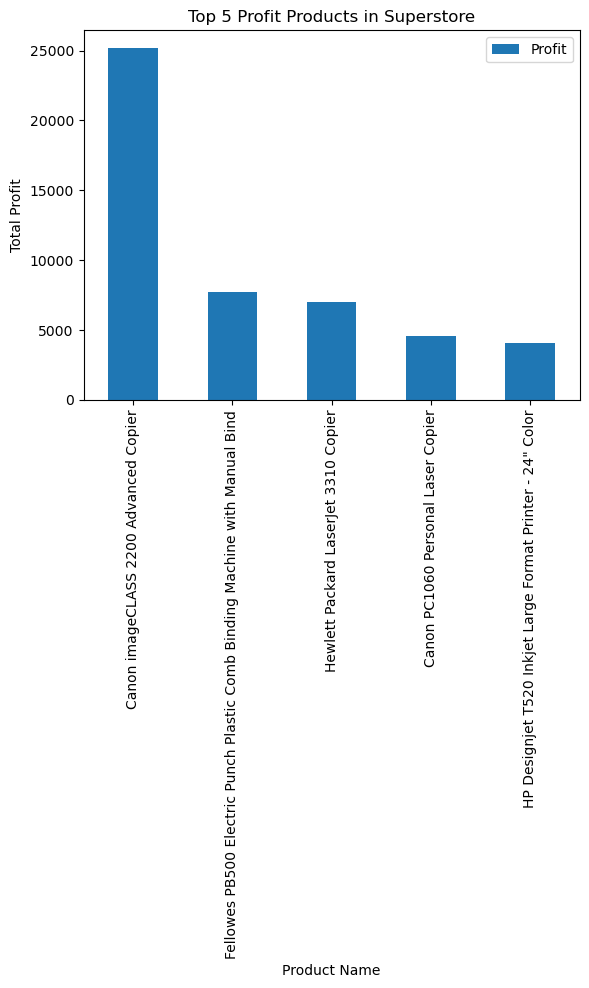

In [29]:
top_5_profit_products.plot(kind="bar")

plt.title("Top 5 Profit Products in Superstore")

plt.xlabel("Product Name")
plt.ylabel("Total Profit")

plt.show()

### Are the top-selling products the most profitable

In [30]:
top_5_profit_products.index


Index(['Canon imageCLASS 2200 Advanced Copier',
       'Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind',
       'Hewlett Packard LaserJet 3310 Copier',
       'Canon PC1060 Personal Laser Copier',
       'HP Designjet T520 Inkjet Large Format Printer - 24" Color'],
      dtype='object', name='Product Name')

In [31]:
top_5_profit_products.index == top_5_selling_products.index


array([ True,  True, False, False, False])

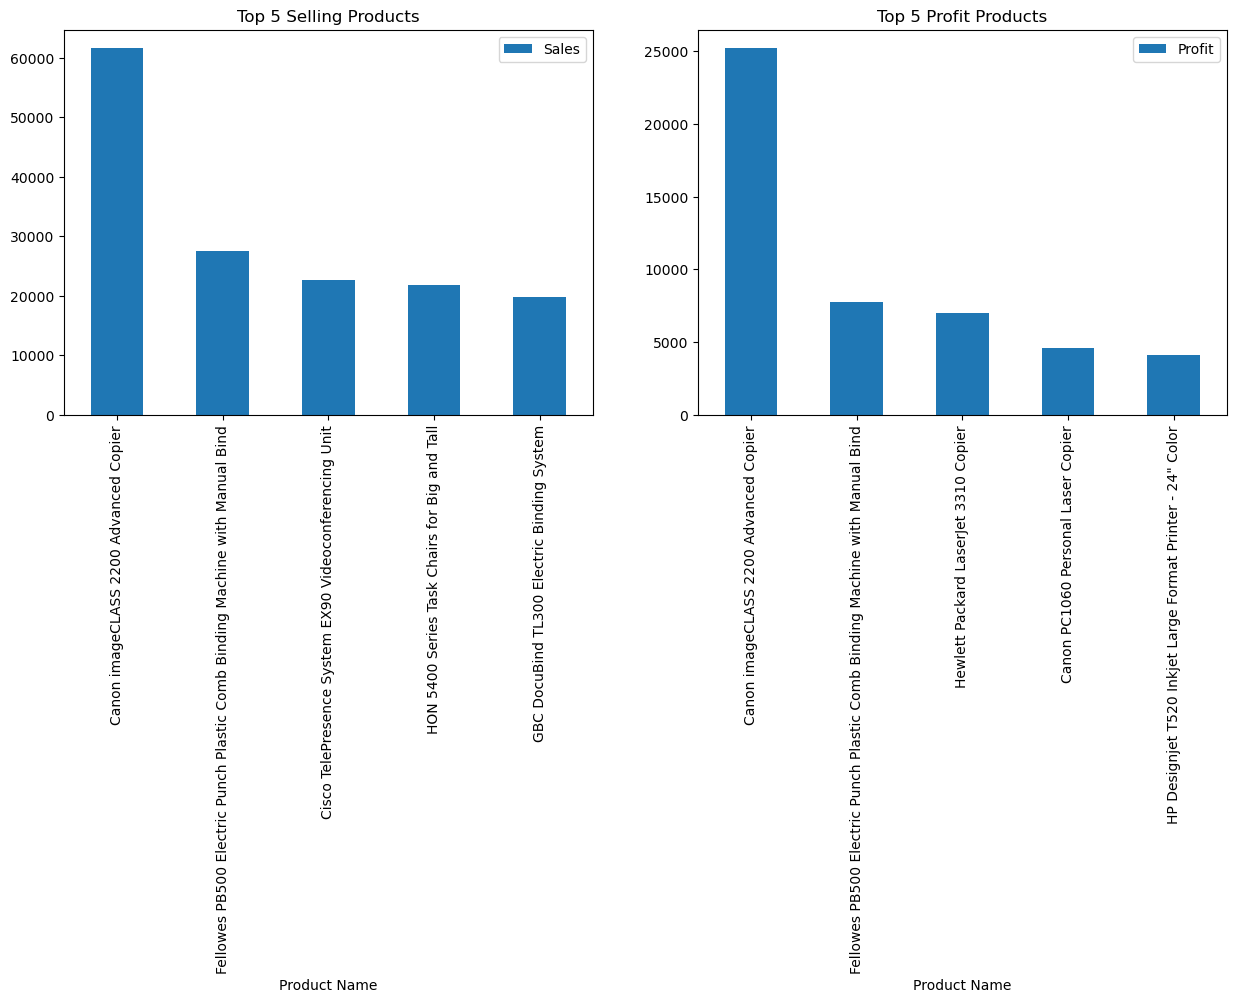

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5))

top_5_selling_products.plot(kind="bar", y="Sales", ax=ax1)

ax1.set_title("Top 5 Selling Products")

top_5_profit_products.plot(kind="bar", y="Profit", ax=ax2)

ax2.set_title("Top 5 Profit Products")

plt.show()

#### Now we can conclude some things¶
#### top_5_selling_products:

- Canon imageCLASS 2200 Advanced Copier
- Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind
- Cisco TelePresence System EX90 Videoconferencing Unit
- HON 5400 Series Task Chairs for Big and Tall
- GBC DocuBind TL300 Electric Binding System
#### top_5_profit_products:

- Canon imageCLASS 2200 Advanced Copier
- Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind
- Hewlett Packard LaserJet 3310 Copier
- Canon PC1060 Personal Laser Copier
- HP Designjet T520 Inkjet Large Format Printer - 24" Color
- The highest selling products, and the most profitable
#### The highest selling products, and the most profitable

- Canon imageCLASS 2200 Advanced Copier
- Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bin

In [33]:
df.Region.value_counts()

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

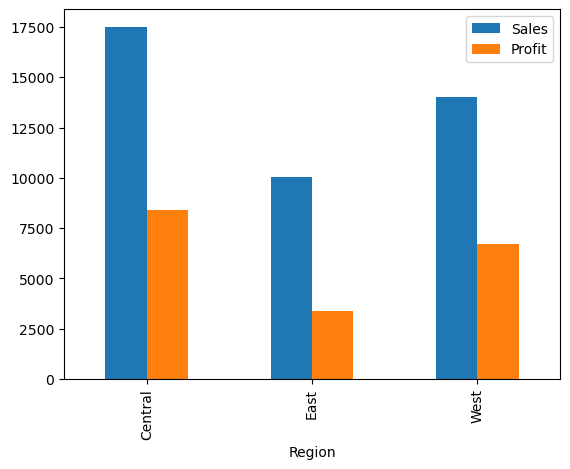

In [35]:
# Filter the data to only include the Canon imageCLASS 2200 Advanced Copier
product = df[df["Product Name"] == "Canon imageCLASS 2200 Advanced Copier"]

# Select ["Sales", "Profit"] BEFORE taking the mean
region_group = product.groupby(["Region"])[["Sales", "Profit"]].mean()
region_group.plot(kind="bar")

plt.show()

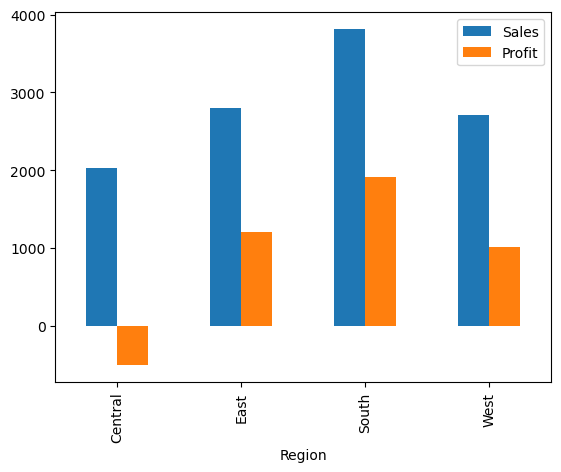

In [37]:
# Filter the data for the new product
product = df[df["Product Name"] == "Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind"]

# Select your columns BEFORE running .mean()
region_group = product.groupby(["Region"])[["Sales", "Profit"]].mean()
region_group.plot(kind="bar")

plt.show()

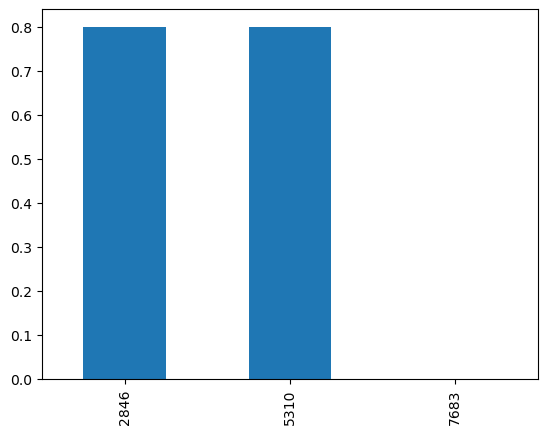

In [39]:
product = df[(df["Product Name"] == "Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind") & (df["Region"] == "Central")]

product["Discount"].plot(kind="bar")

plt.show()

- The company loses when it sells its Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind products in the Central! as it make 80% discount on 2 products from 3 products


### What is the sales trend over time (monthly, yearly)

In [40]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

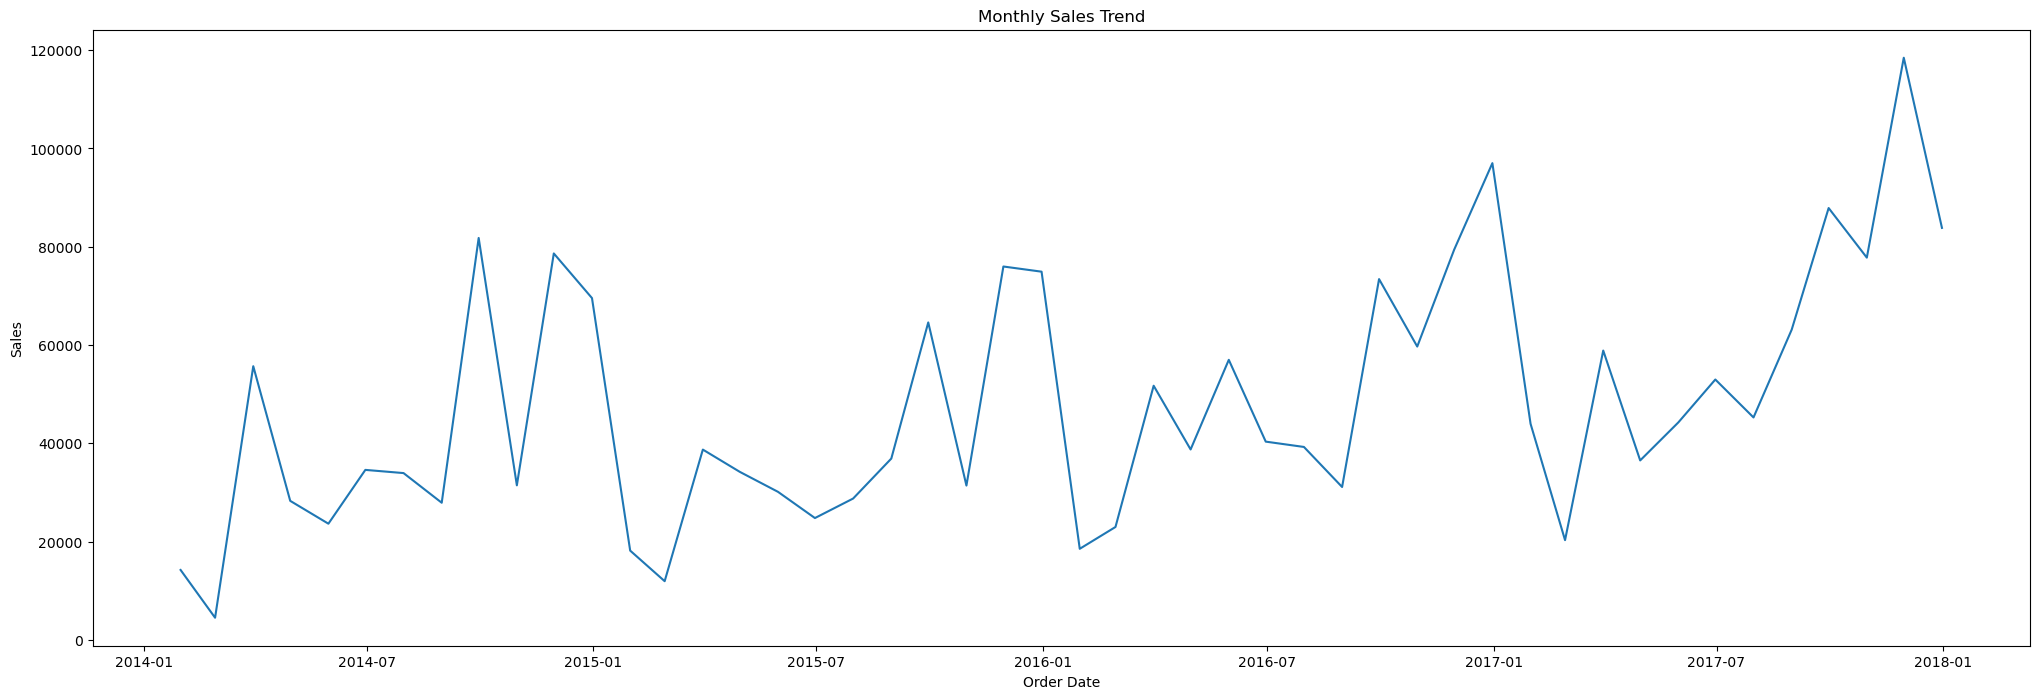

In [47]:
monthly_sales = df.groupby(['Order Date'], as_index=False).sum()

monthly_sales = monthly_sales.set_index('Order Date')

monthly_sales = monthly_sales.resample('M').sum() # M for month

# Plot
plt.figure(figsize=(25,8))
plt.plot(monthly_sales['Sales'])
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.title("Monthly Sales Trend")
plt.show()


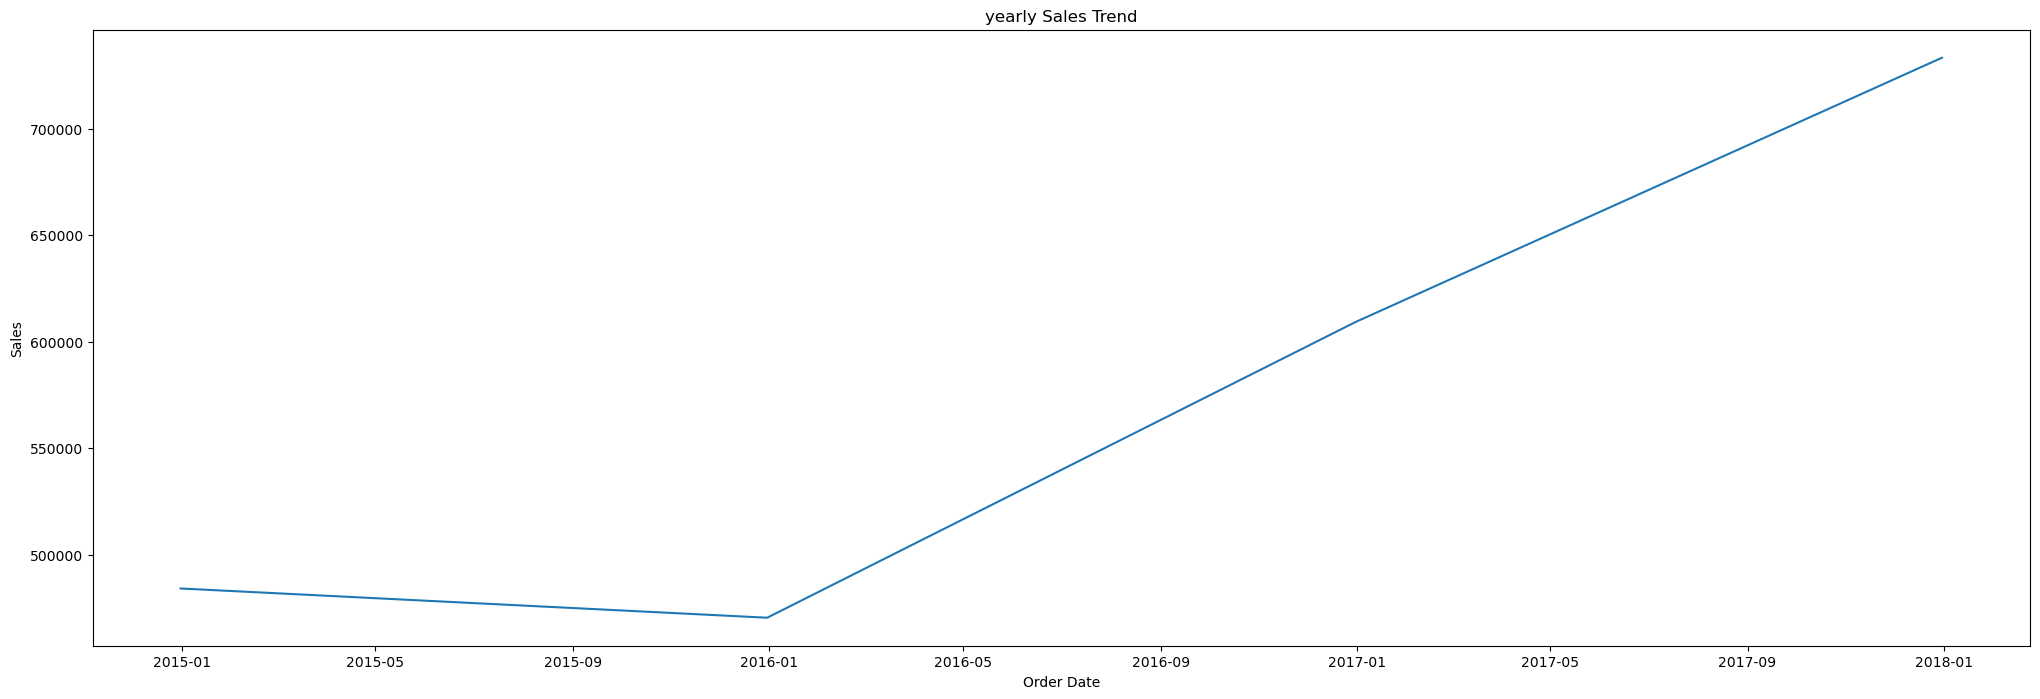

In [48]:
yearly_sales = monthly_sales.resample('Y').sum() 


plt.figure(figsize=(25,8))
plt.plot(yearly_sales['Sales'])
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.title("yearly Sales Trend")
plt.show()

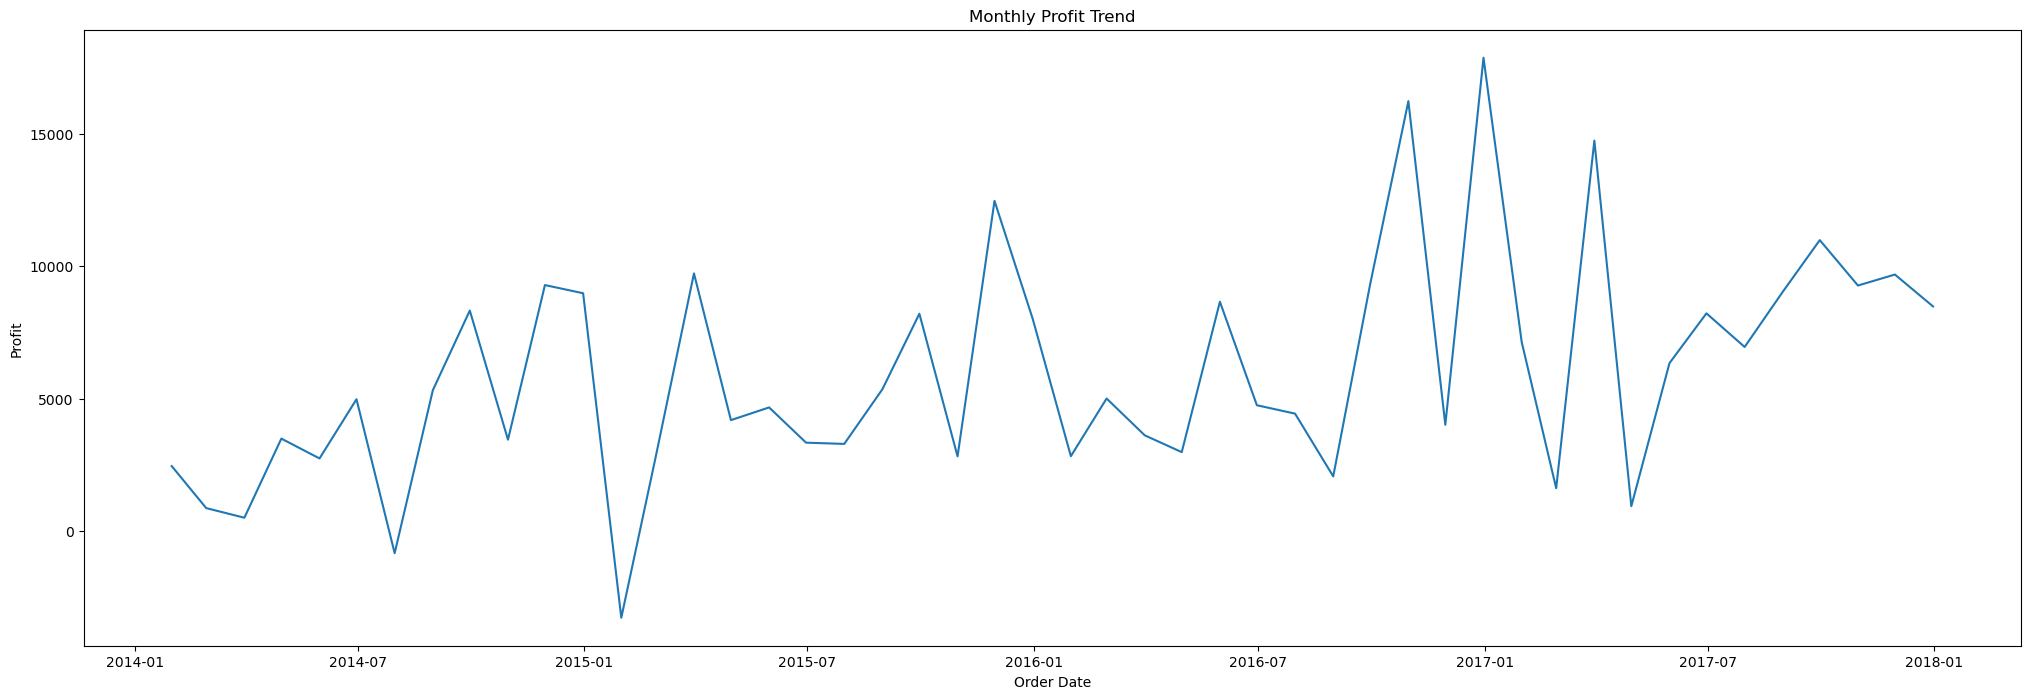

In [49]:
monthly_sales = df.groupby(['Order Date'], as_index=False).sum()

monthly_sales = monthly_sales.set_index('Order Date')

monthly_sales = monthly_sales.resample('M').sum() # M for month

# Plot
plt.figure(figsize=(25,8))
plt.plot(monthly_sales['Profit'])
plt.xlabel("Order Date")
plt.ylabel("Profit")
plt.title("Monthly Profit Trend")
plt.show()

- The general trend of the company is profit, but there are some periods in which profits decrease and then rise again. I think it's because of the discounts

### Which region & place generates the most sales

In [51]:
df_places = df[['Country','City','State','Region']]
df_places.head()


,Country,City,State,Region
0,United States,Henderson,Kentucky,South
1,United States,Henderson,Kentucky,South
2,United States,Los Angeles,California,West
3,United States,Fort Lauderdale,Florida,South
4,United States,Fort Lauderdale,Florida,South


In [52]:
for place in df_places.columns:
    print(place,':',df_places[place].nunique())

Country : 1
City : 531
State : 49
Region : 4


In [53]:
df_places = df[['City','State','Region','Sales','Profit']]
df_places.head()

,City,State,Region,Sales,Profit
0,Henderson,Kentucky,South,261.9600,41.9136
1,Henderson,Kentucky,South,731.9400,219.5820
2,Los Angeles,California,West,14.6200,6.8714
3,Fort Lauderdale,Florida,South,957.5775,-383.0310
4,Fort Lauderdale,Florida,South,22.3680,2.5164


#### Group the data by Region and City and calculate the total sales for each group

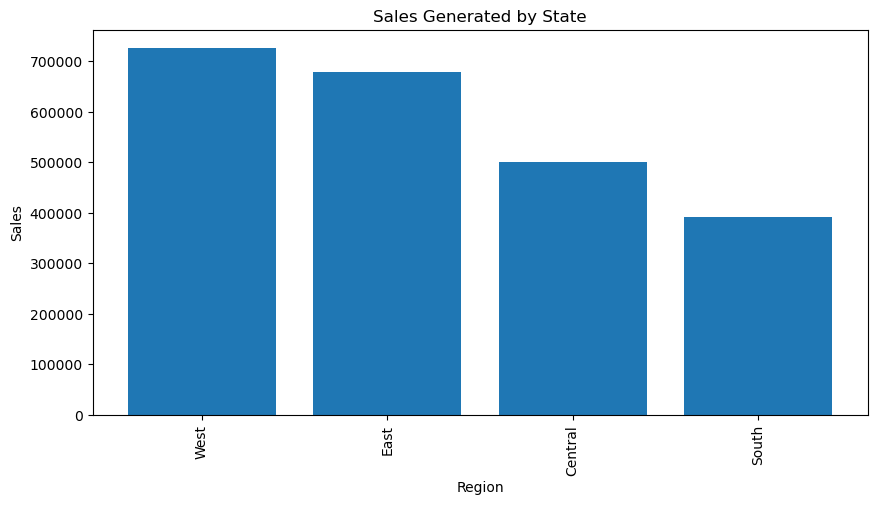

In [61]:
grouped_data = df_places.groupby(['Region'], as_index=False).sum()
grouped_data.sort_values(by='Sales', ascending=False, inplace=True)

plt.figure(figsize=(10,5))
plt.bar(grouped_data['Region'], grouped_data['Sales'], align='center',)
plt.xlabel("Region")
plt.ylabel("Sales")
plt.title("Sales Generated by State")
plt.xticks(rotation=90)

plt.show()

#### Group the data by Region and City and calculate the total sales for each group


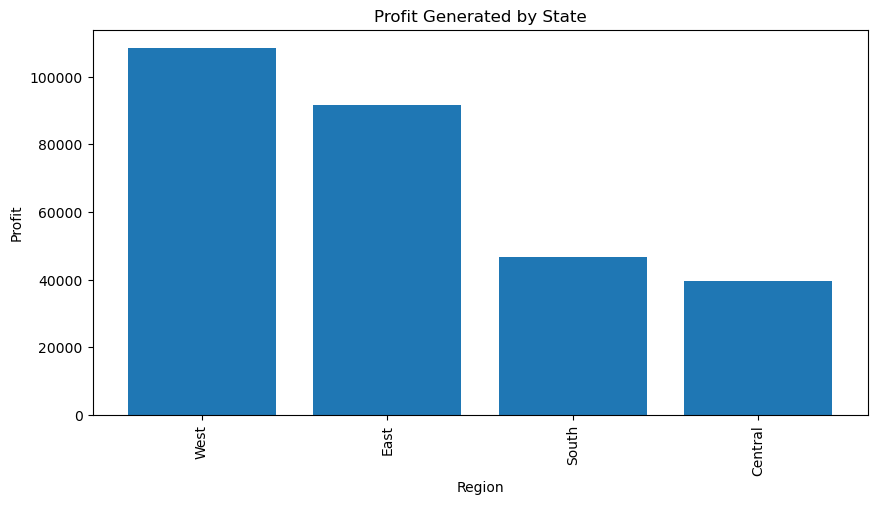

In [60]:
grouped_data = df_places.groupby(['Region'], as_index=False).sum()
grouped_data.sort_values(by='Profit', ascending=False, inplace=True)

plt.figure(figsize=(10,5))
plt.bar(grouped_data['Region'], grouped_data['Profit'], align='center',)
plt.xlabel("Region")
plt.ylabel("Profit")
plt.title("Profit Generated by State")
plt.xticks(rotation=90)

plt.show()

#### Sales Generated by State

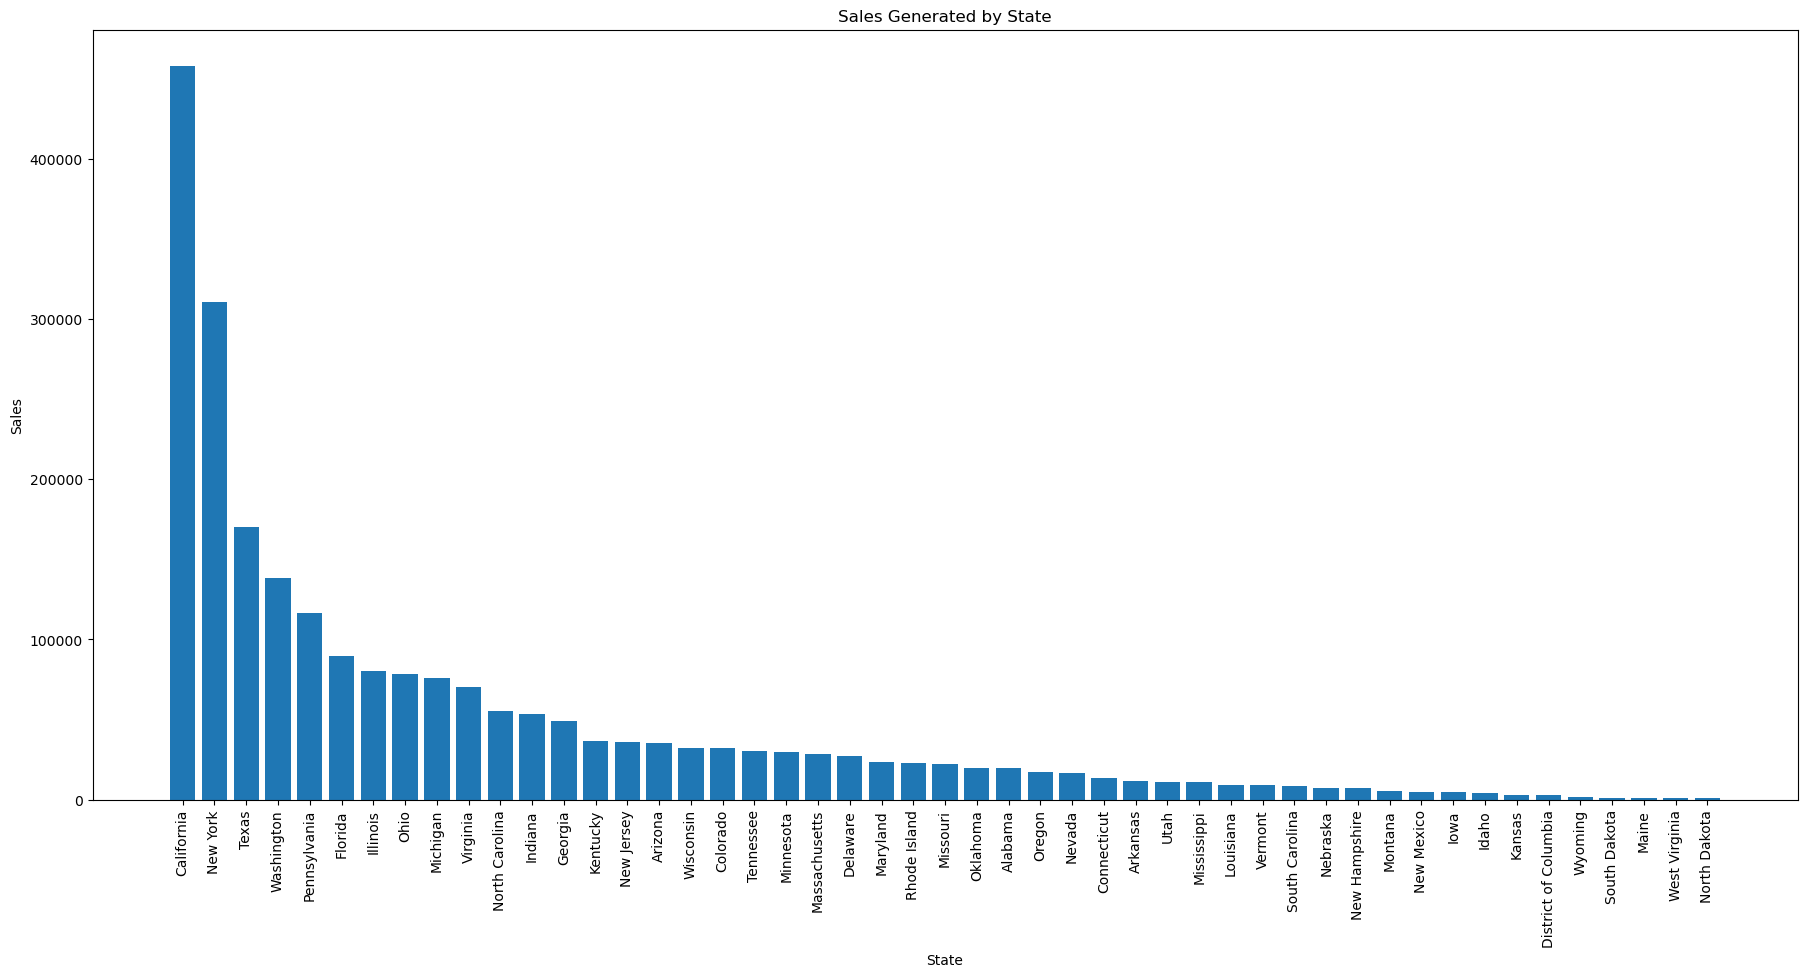

In [57]:
grouped_data = df_places.groupby(['State'], as_index=False).sum()
grouped_data.sort_values(by='Sales', ascending=False, inplace=True)


plt.figure(figsize=(22,10))
plt.bar(grouped_data['State'], grouped_data['Sales'], align='center',)
plt.xlabel("State")
plt.ylabel("Sales")
plt.title("Sales Generated by State")
plt.xticks(rotation=90)

plt.show()

#### Select the top 5 cities(Sales)


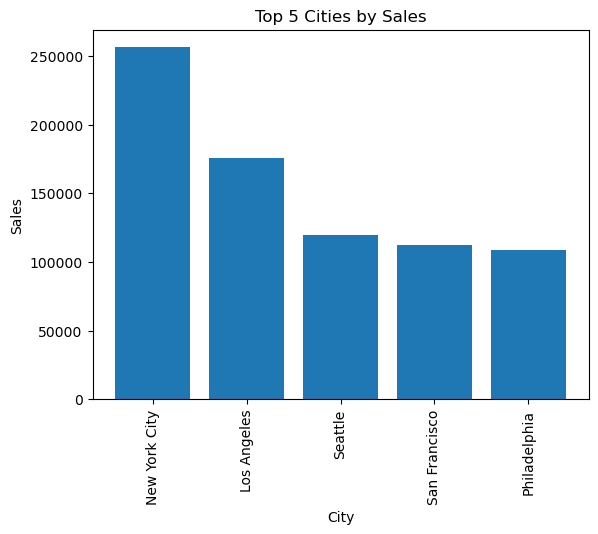

In [58]:
grouped_data = df_places.groupby('City', as_index=False).sum()

grouped_data.sort_values(by='Sales', ascending=False, inplace=True)

top_5_cities = grouped_data.head()

plt.bar(top_5_cities['City'], top_5_cities['Sales'], align='center')
plt.xlabel("City")
plt.ylabel("Sales")
plt.title("Top 5 Cities by Sales")
plt.xticks(rotation=90)

plt.show()

#### Select the top 5 cities (Profit)

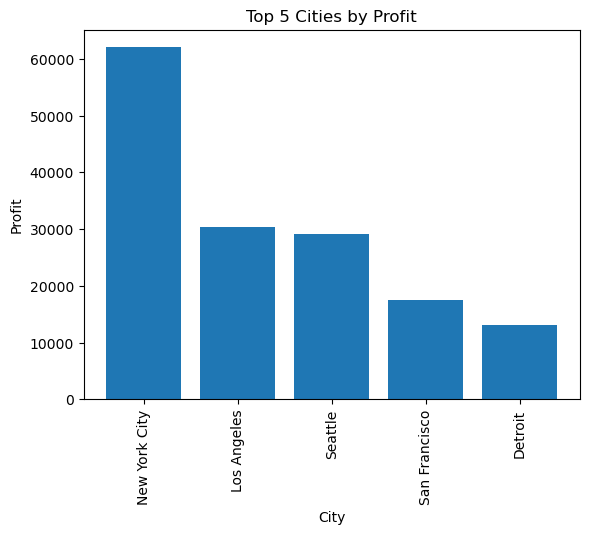

In [59]:
grouped_data = df_places.groupby('City', as_index=False).sum()

grouped_data.sort_values(by='Profit', ascending=False, inplace=True)

top_5_cities = grouped_data.head()

plt.bar(top_5_cities['City'], top_5_cities['Profit'], align='center')
plt.xlabel("City")
plt.ylabel("Profit")
plt.title("Top 5 Cities by Profit")
plt.xticks(rotation=90)

plt.show()

In [64]:
top_5_cities.City

329    New York City
266      Los Angeles
452          Seattle
438    San Francisco
123          Detroit
Name: City, dtype: object

- top placies are:
- Cities: [New York City, Los Angeles, Seattle, San Francisco, Detroit]

- State : [california, New York]

- Region : [West]

### What is the impact of discounts on sales

In [65]:
df.Discount.value_counts()


Discount
0.00    4798
0.20    3657
0.70     418
0.80     300
0.30     227
0.40     206
0.60     138
0.10      94
0.50      66
0.15      52
0.32      27
0.45      11
Name: count, dtype: int64

#### Group the data by the discount and compute the average sales

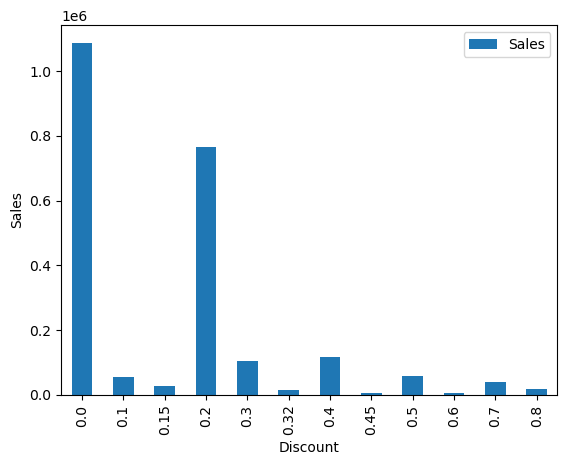

In [67]:
discount_group = df.groupby(["Discount"])[["Sales"]].sum()

ax = discount_group.plot(kind="bar")
ax.set_ylabel("Sales")

plt.show()

#### Create a scatter plot between sales and discounts


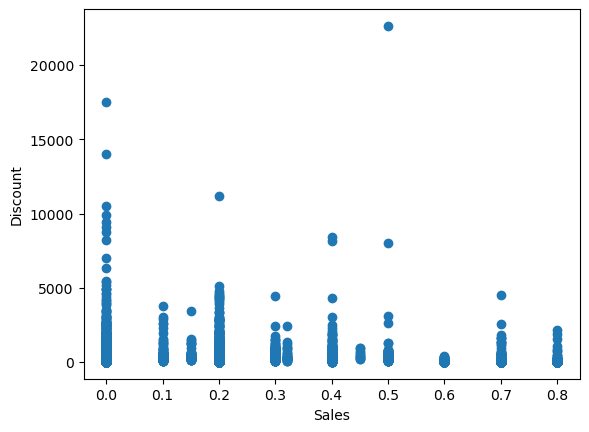

In [68]:
plt.scatter(df['Discount'], df['Sales'])

plt.ylabel("Discount")
plt.xlabel("Sales")
plt.show()

#### Group the data by the discount and compute the average sales


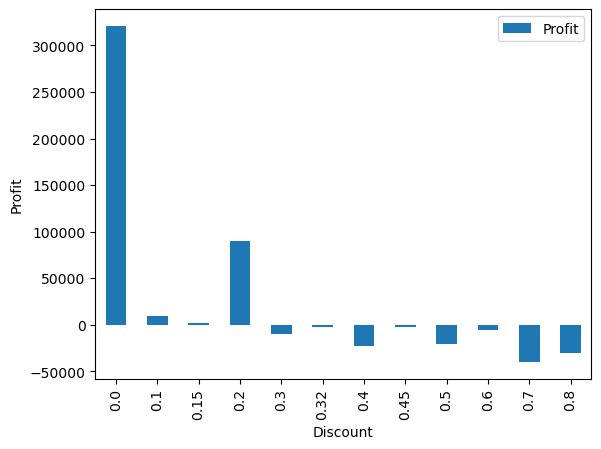

In [70]:
discount_group = df.groupby(["Discount"])[["Profit"]].sum()

ax = discount_group.plot(kind="bar")
ax.set_ylabel("Profit")

plt.show()

In [75]:
sales_90th_percentile = df['Sales'].quantile(0.90)

# Filter the data to show only the values greater than ..% in sales
df_90 = df[df['Sales'] > sales_90th_percentile]

In [76]:
sales_90th_percentile


572.7060000000001

In [77]:
df_90.shape


(1000, 21)

In [78]:
df.shape


(9994, 21)

- the best salles
- The best sales are when the discount is 50%, but this leads to loss and non-profitability.

- The discount from 10 to 20%. Is the best solution, as they are the second and third best sellers and make profits

#### Group the data by product category and calculate the average profit for each category


In [79]:
avg_profit_margin_by_category = df.groupby('Category')['Profit'].mean()

print(avg_profit_margin_by_category)

Category
Furniture           8.699327
Office Supplies    20.327050
Technology         78.752002
Name: Profit, dtype: float64


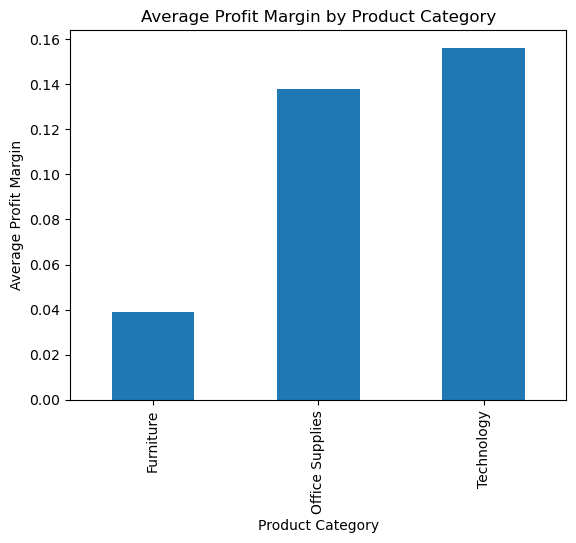

In [80]:
df['Profit Margin'] = df['Profit'] / df['Sales']

# Group the data by product category and calculate the average profit margin for each category
avg_profit_margin_by_category = df.groupby('Category')['Profit Margin'].mean()

# Plot the average profit margin for each category as a bar chart
avg_profit_margin_by_category.plot(kind='bar')

# Add a title and labels to the chart
plt.title("Average Profit Margin by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Profit Margin")

plt.show()

## Customers

In [82]:
df.Segment.value_counts()


Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

In [83]:
df['Ship Mode'].value_counts()


Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

In [84]:
pivot_table = df.pivot_table(index='Segment', columns='Ship Mode', values='Sales', aggfunc='sum')

In [85]:
pivot_table

Ship Mode,First Class,Same Day,Second Class,Standard Class
Segment,,,,
Consumer,159168.9650,60596.359,231498.9496,710137.0714
Corporate,105858.4699,45121.323,146126.0388,409040.5351
Home Office,86400.9880,22645.443,81568.5810,239038.1365


### Plot the pivot table as a bar chart


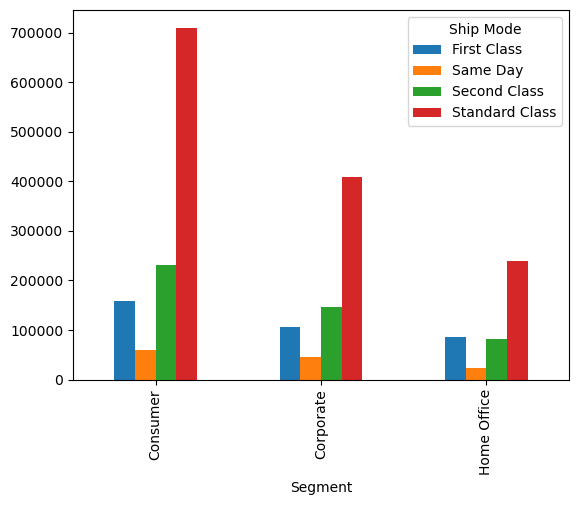

In [87]:
pivot_table.plot(kind='bar', stacked=False)

plt.show()

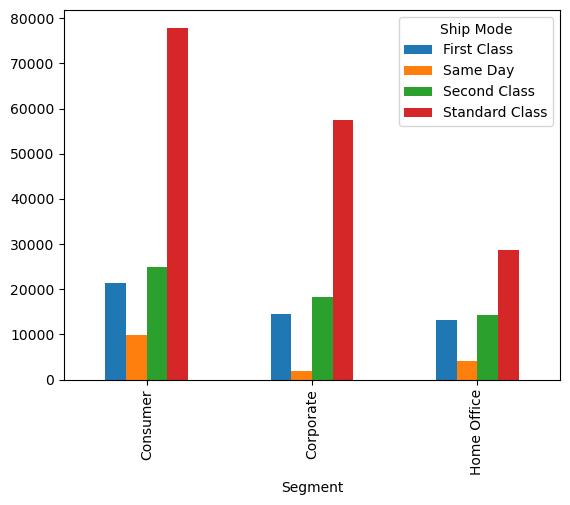

In [88]:
pivot_table = df.pivot_table(index='Segment', columns='Ship Mode', values='Profit', aggfunc='sum')

pivot_table.plot(kind='bar', stacked=False)

# Show the plot
plt.show()

- Most of the sales and profits come from (Consumers) who use (standard-class) shipping mode

## Machine Learning


In [103]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [89]:
# 1. Extract Year and Month from Order Date
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month

# 2. Select features (X) and target (y)
# We drop IDs, names, and highly unique fields like 'Product Name' for this basic model
features = ['Segment', 'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount', 'Order Year', 'Order Month']
X = df[features]
y = df['Profit']

# 3. One-Hot Encoding for categorical variables
X = pd.get_dummies(X, columns=['Segment', 'Region', 'Category', 'Sub-Category'], drop_first=True)

print("Features shape after Encoding:", X.shape)
X.head()

Features shape after Encoding: (9994, 28)


,Sales,Quantity,Discount,Order Year,Order Month,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,...,Sub-Category_Envelopes,Sub-Category_Fasteners,Sub-Category_Furnishings,Sub-Category_Labels,Sub-Category_Machines,Sub-Category_Paper,Sub-Category_Phones,Sub-Category_Storage,Sub-Category_Supplies,Sub-Category_Tables
0,261.9600,2,0.00,2016,11,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,731.9400,3,0.00,2016,11,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,14.6200,2,0.00,2016,6,True,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
3,957.5775,5,0.45,2015,10,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
4,22.3680,2,0.20,2015,10,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [90]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training shapes: {X_train.shape}, Testing shapes: {X_test.shape}")

Training shapes: (7995, 28), Testing shapes: (1999, 28)


In [91]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Model training completed successfully!")

Model training completed successfully!


### Make predictions

In [96]:
y_pred = rf_model.predict(X_test)

# Calculate Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score (Accuracy/Variance Explained): {r2:.4f}")

Root Mean Squared Error (RMSE): 222.60
R² Score (Accuracy/Variance Explained): -0.0219


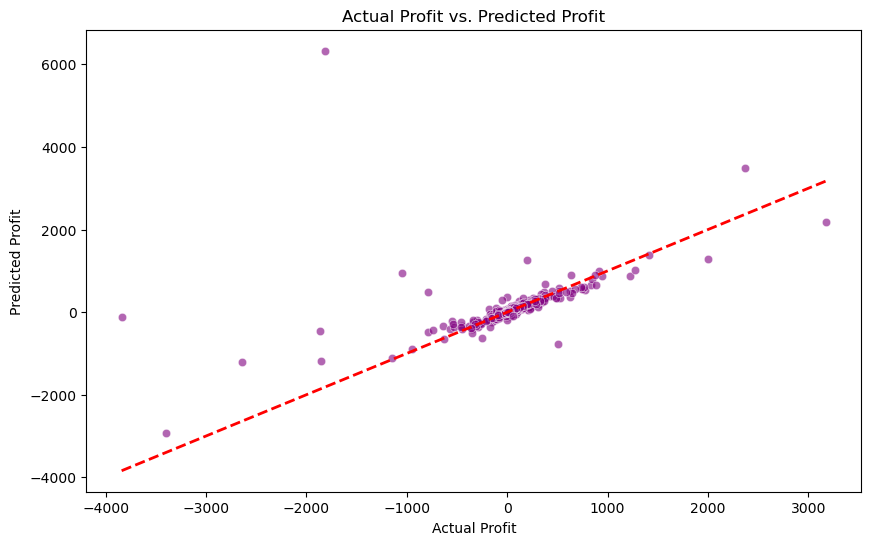

In [97]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction diagonal line

plt.title("Actual Profit vs. Predicted Profit")
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.show()

### Extract feature importances


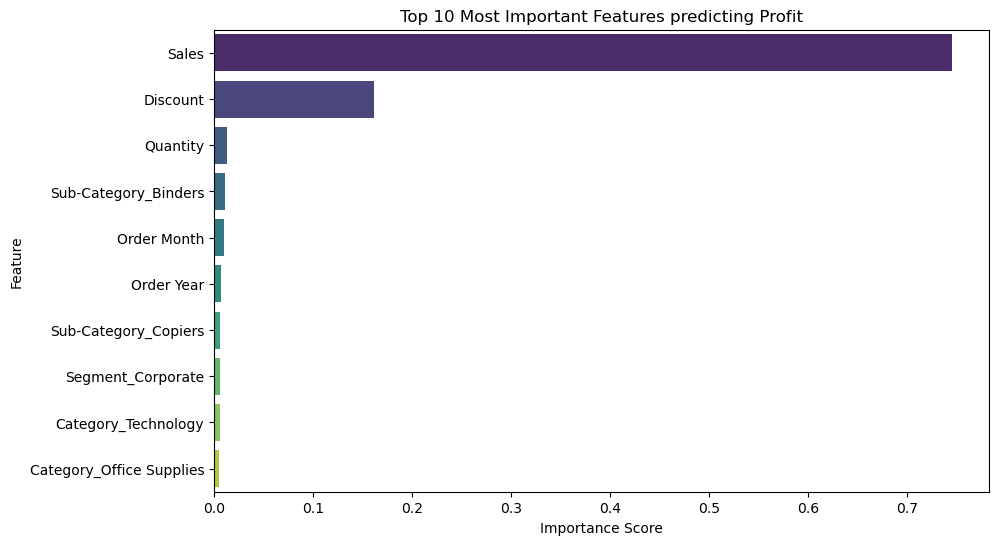

In [98]:
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame sorted by importance
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Plot top 10 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
plt.title("Top 10 Most Important Features predicting Profit")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()